Threshold (50) exclusions — mean MASE>threshold OR mean CRPS>threshold:
  CPCB/H/short: 1 site(s) excluded (CO: 1)
  EEA_DE/H/short: 22 site(s) excluded (NO2: 2, SO2: 20)
  EPA/H/short: 55 site(s) excluded (CO: 2, SO2: 53)


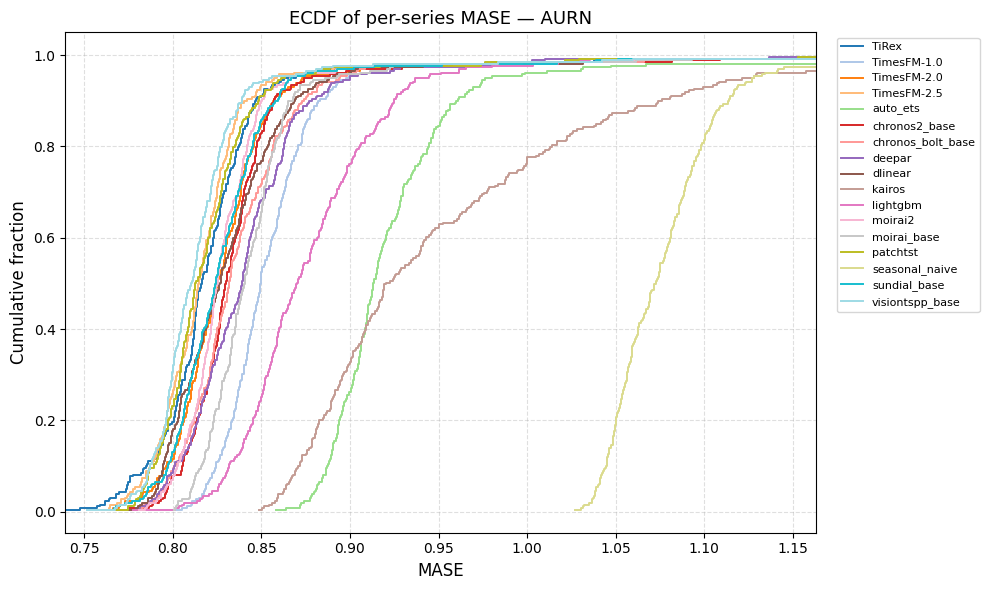

/tmp/ipykernel_70059/3114967861.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


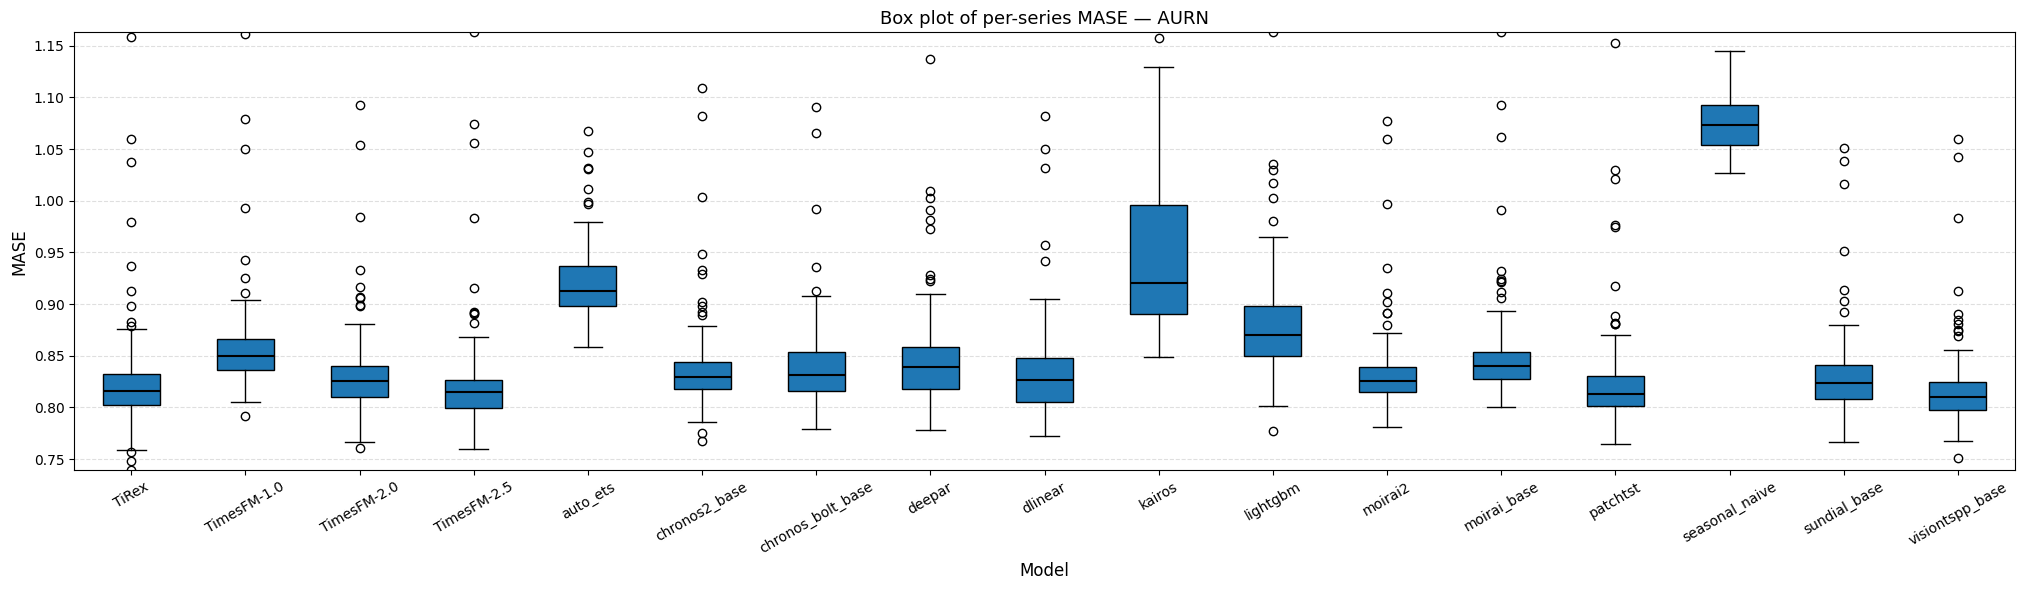

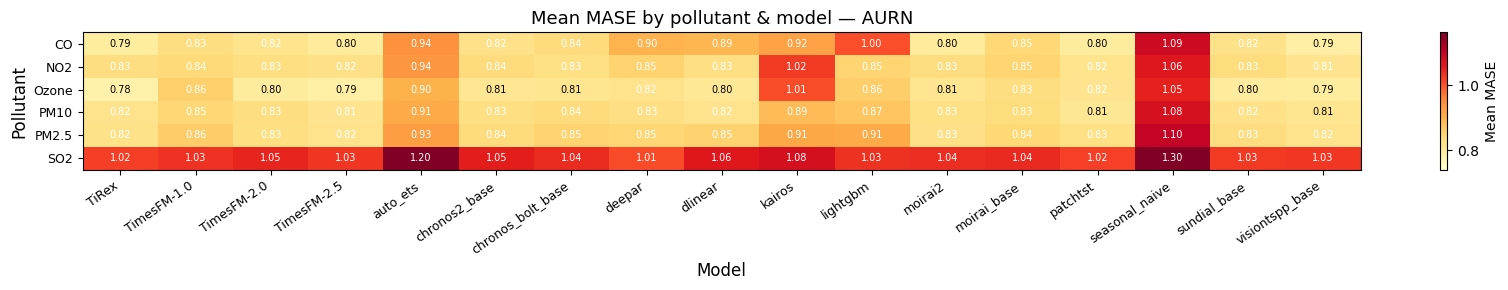

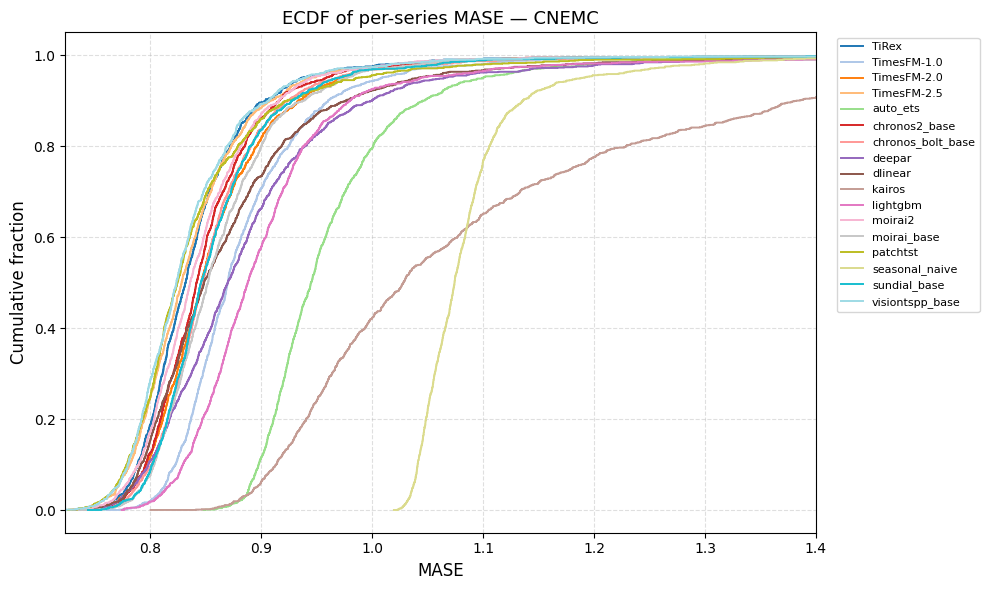

/tmp/ipykernel_70059/3114967861.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


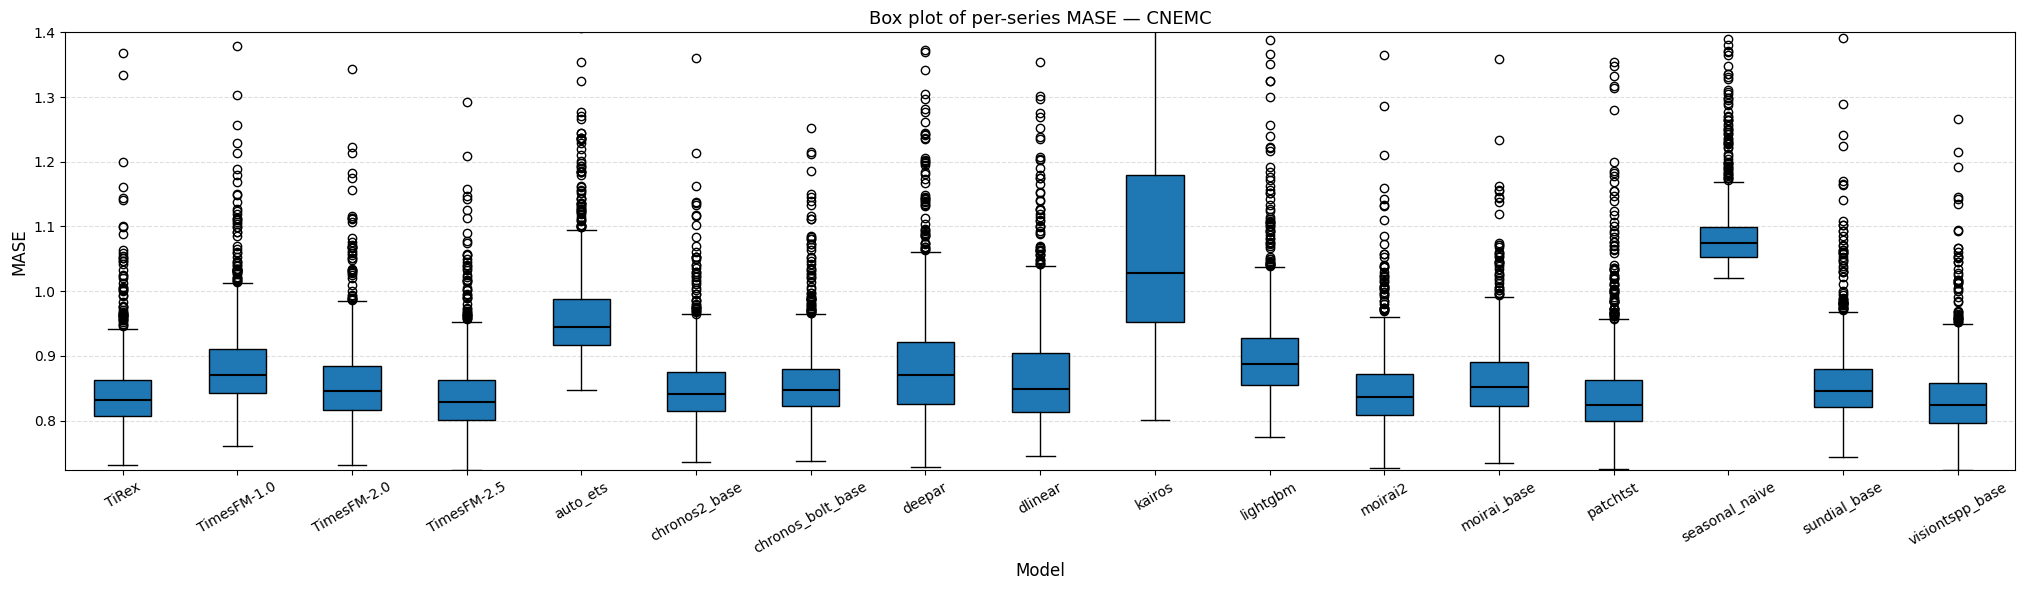

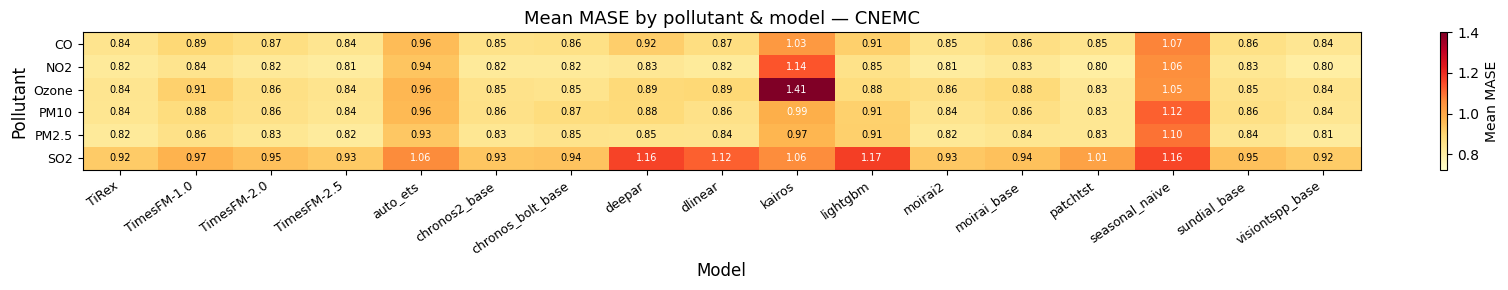

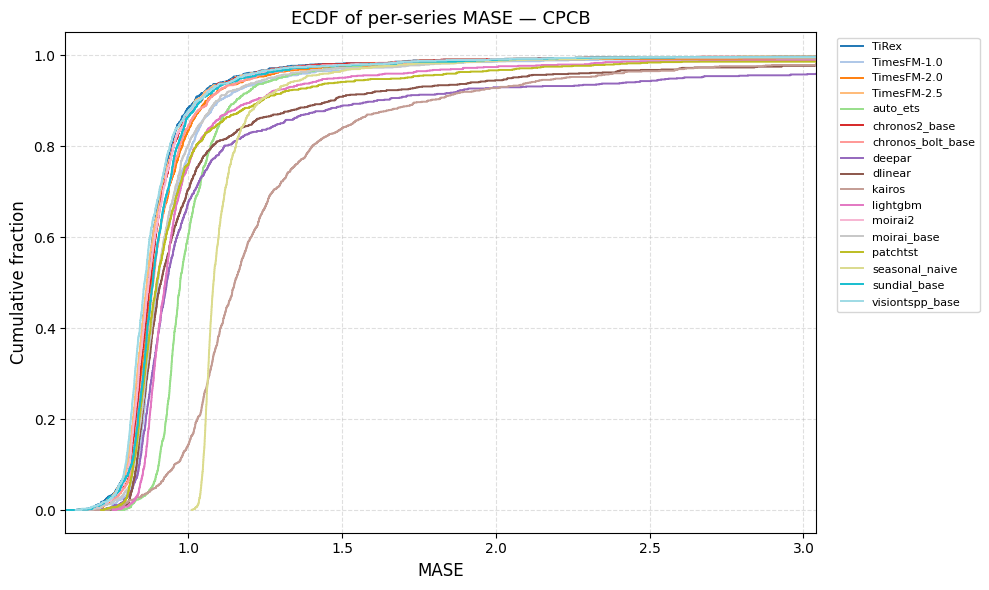

/tmp/ipykernel_70059/3114967861.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


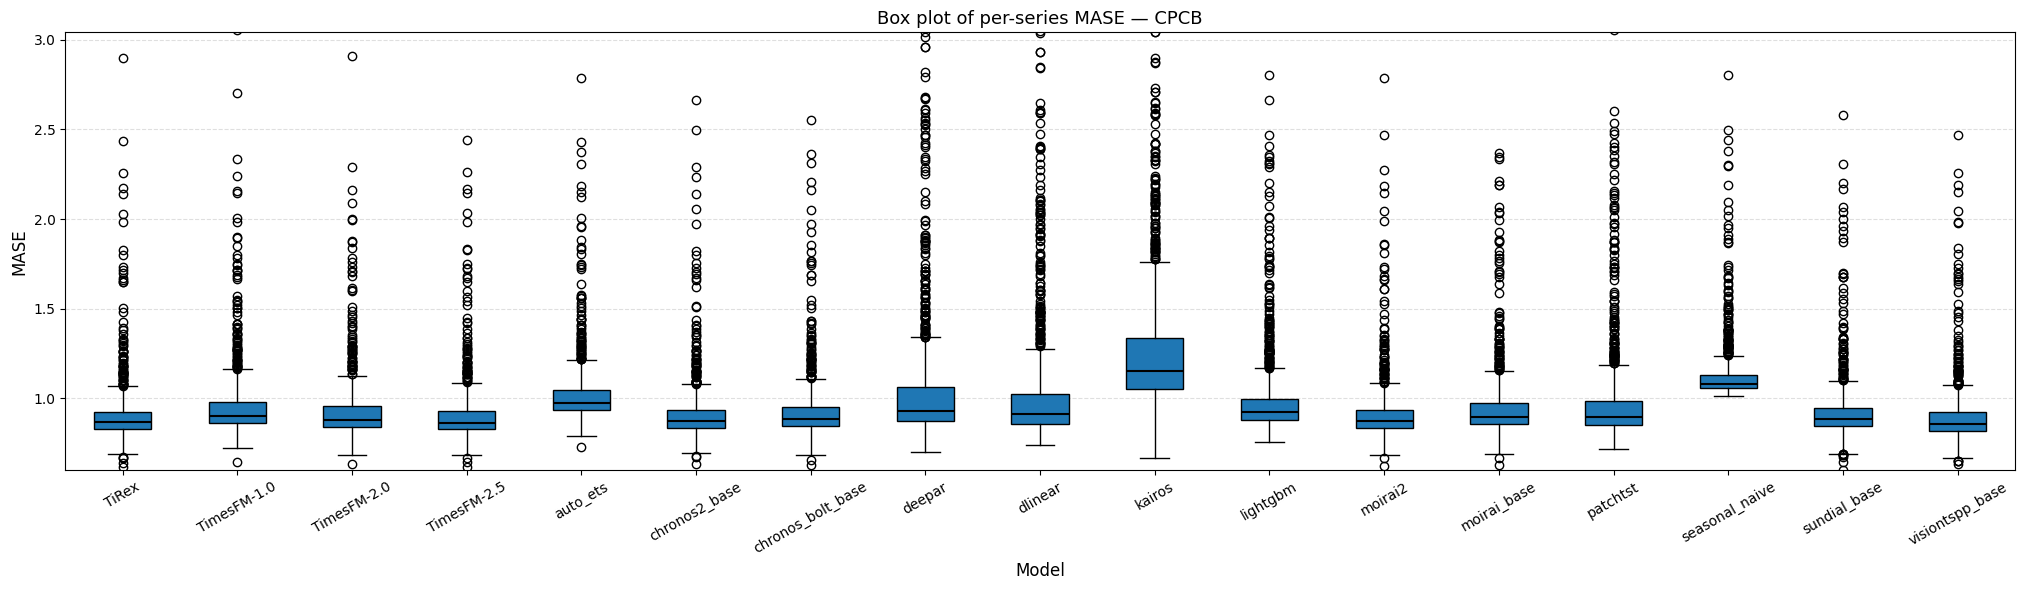

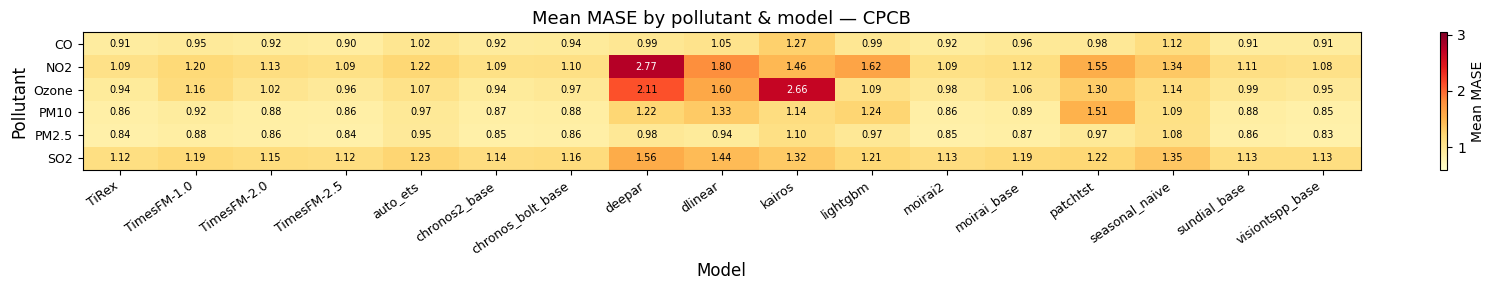

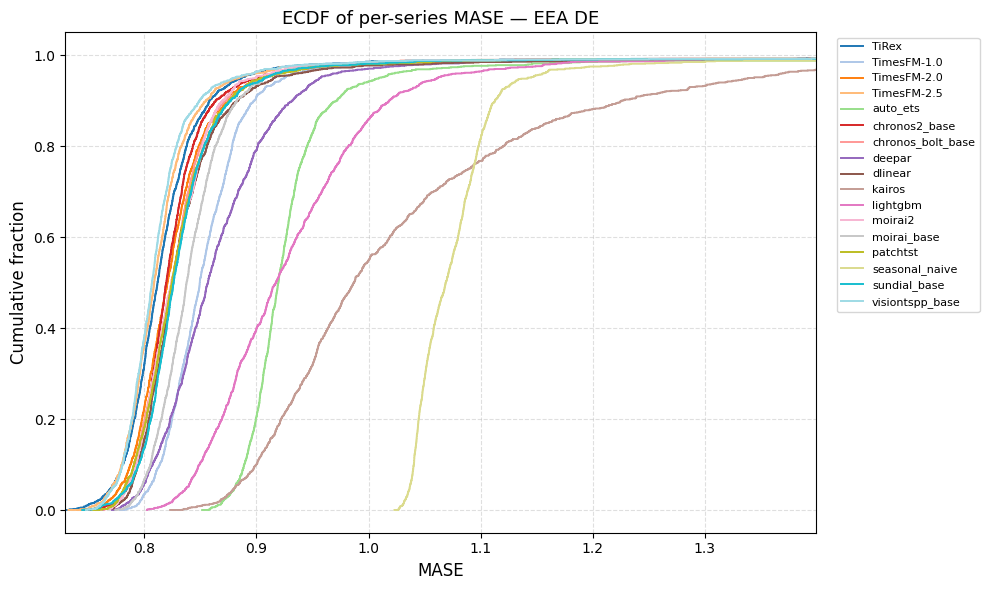

/tmp/ipykernel_70059/3114967861.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


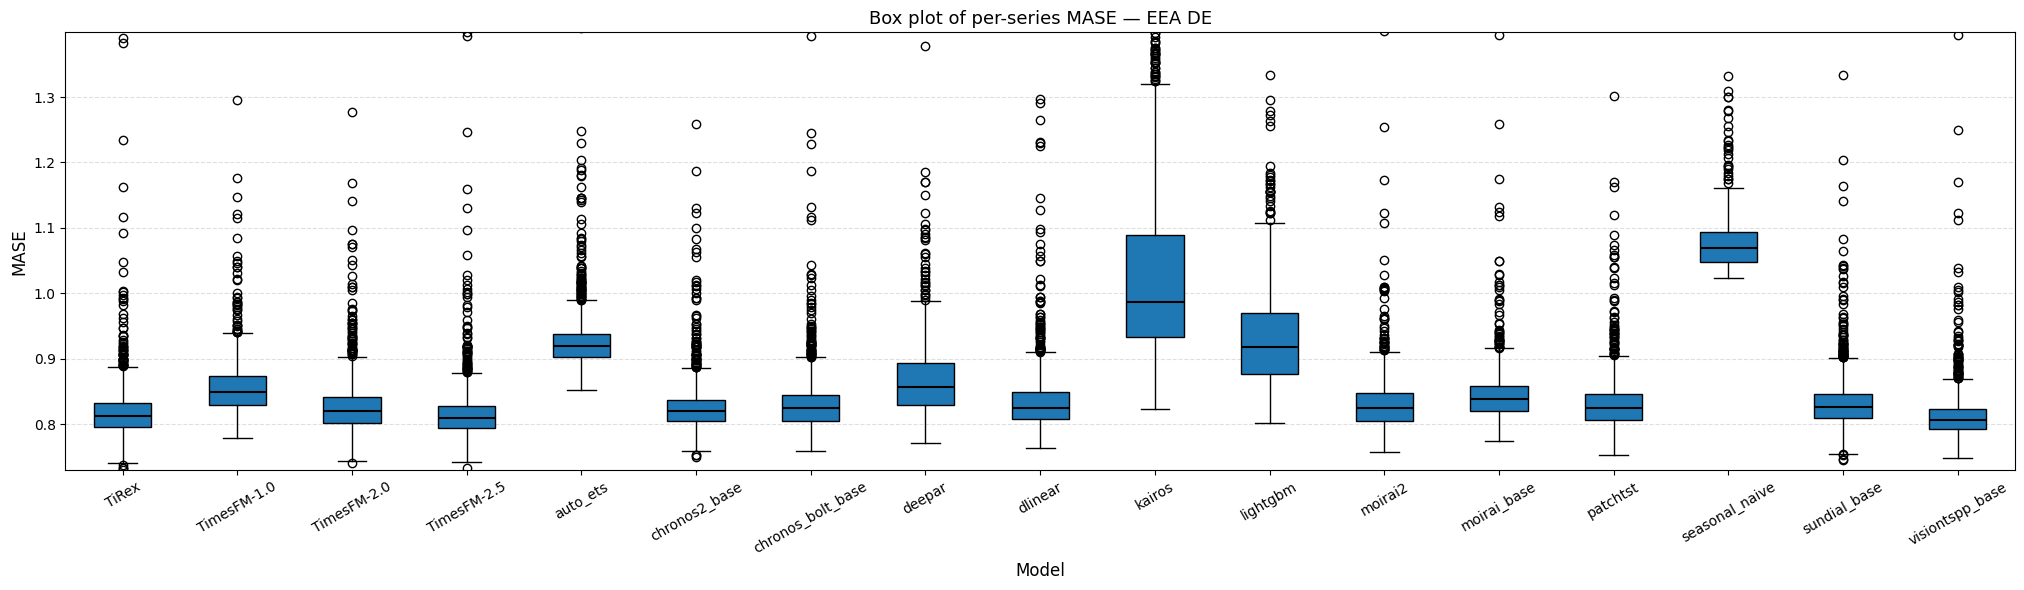

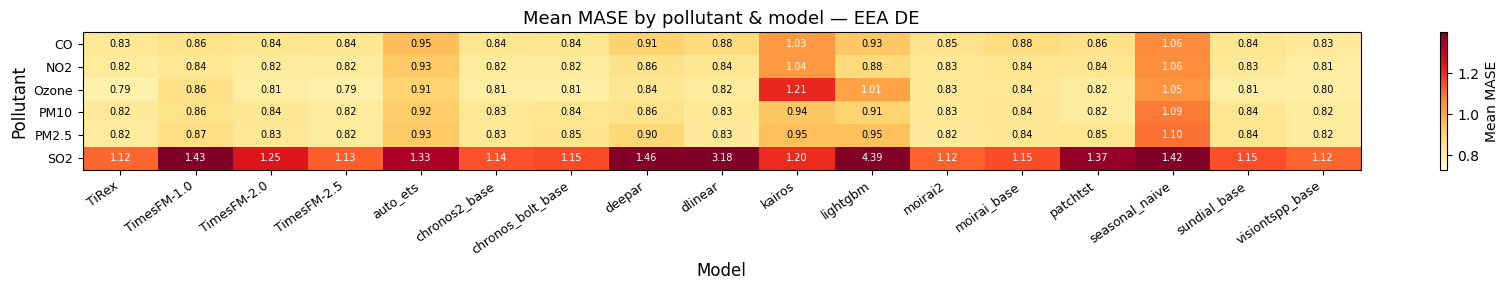

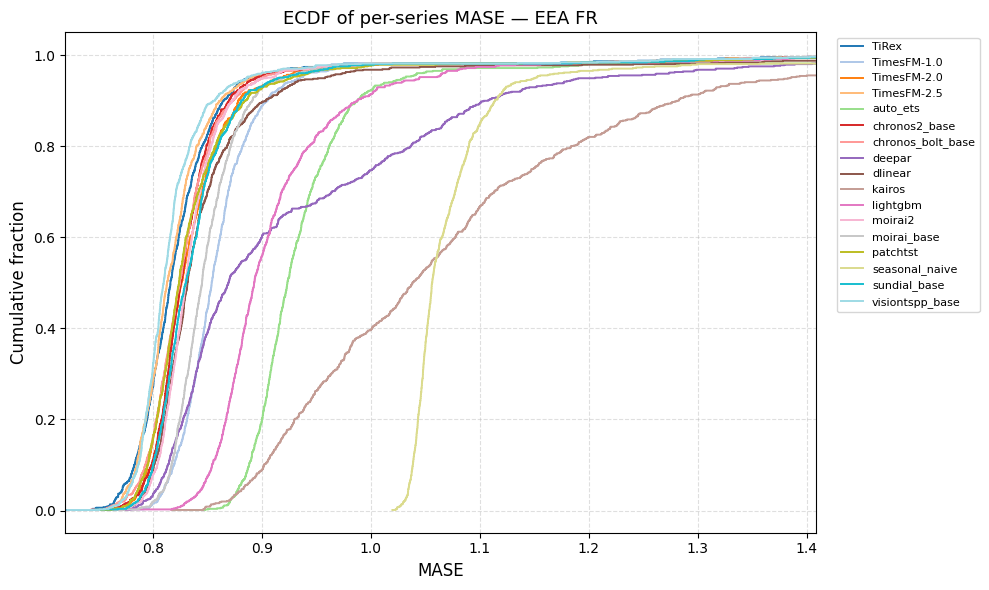

/tmp/ipykernel_70059/3114967861.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


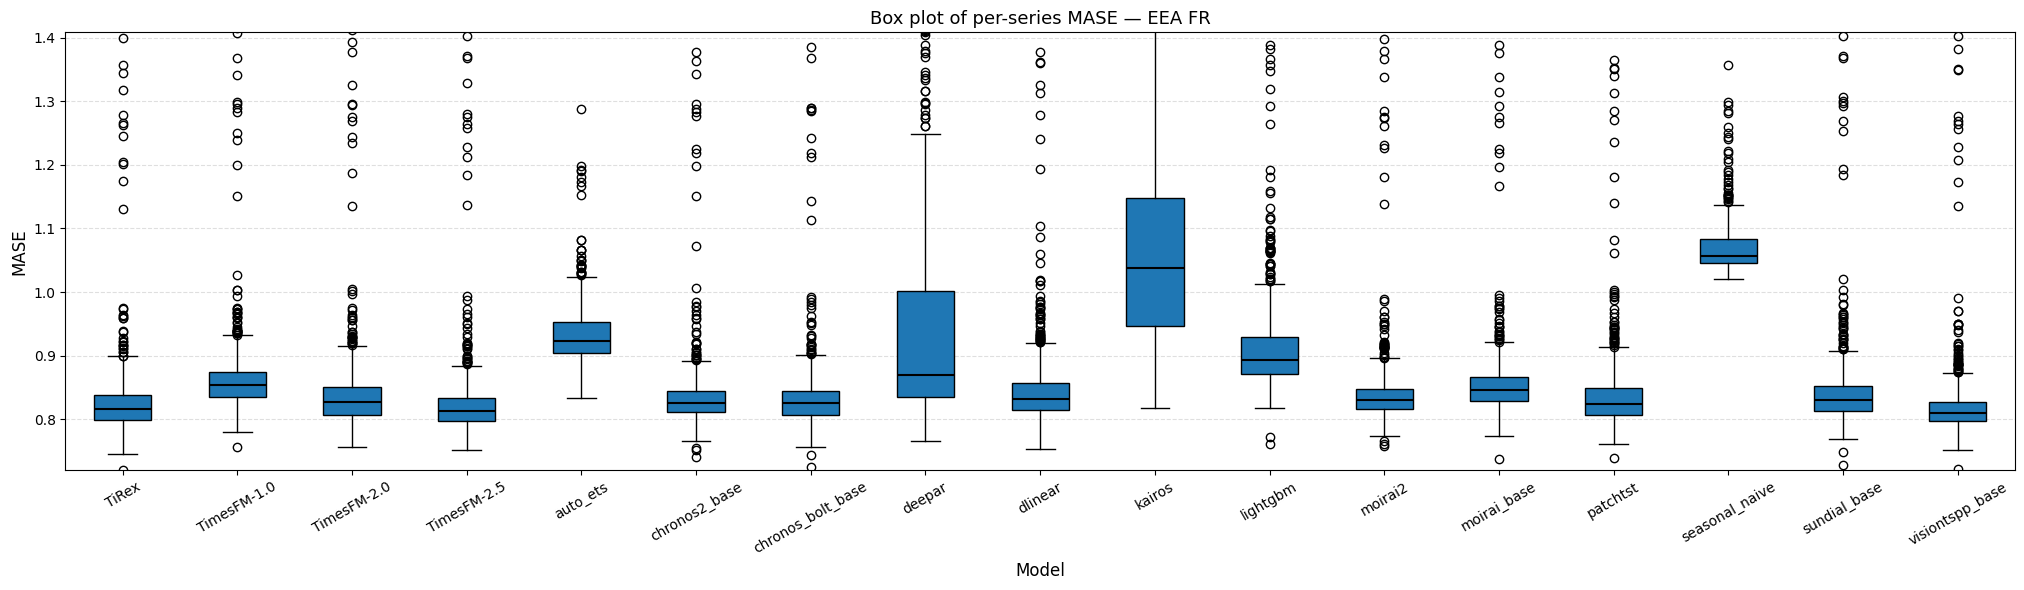

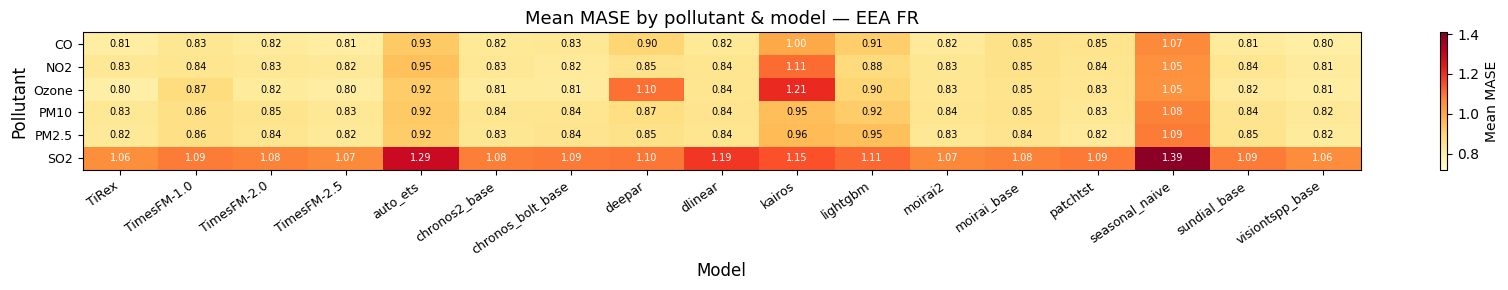

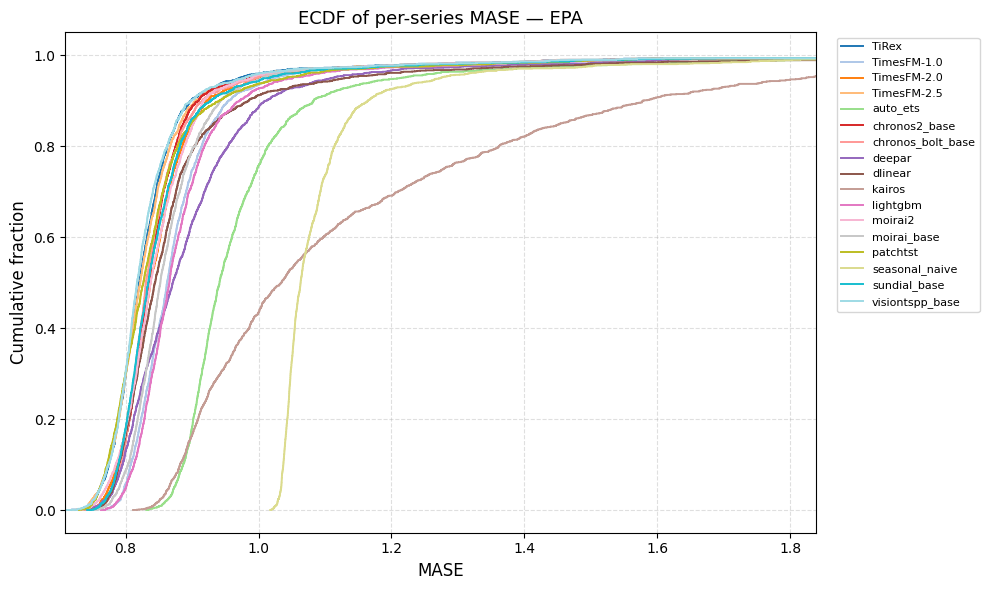

/tmp/ipykernel_70059/3114967861.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


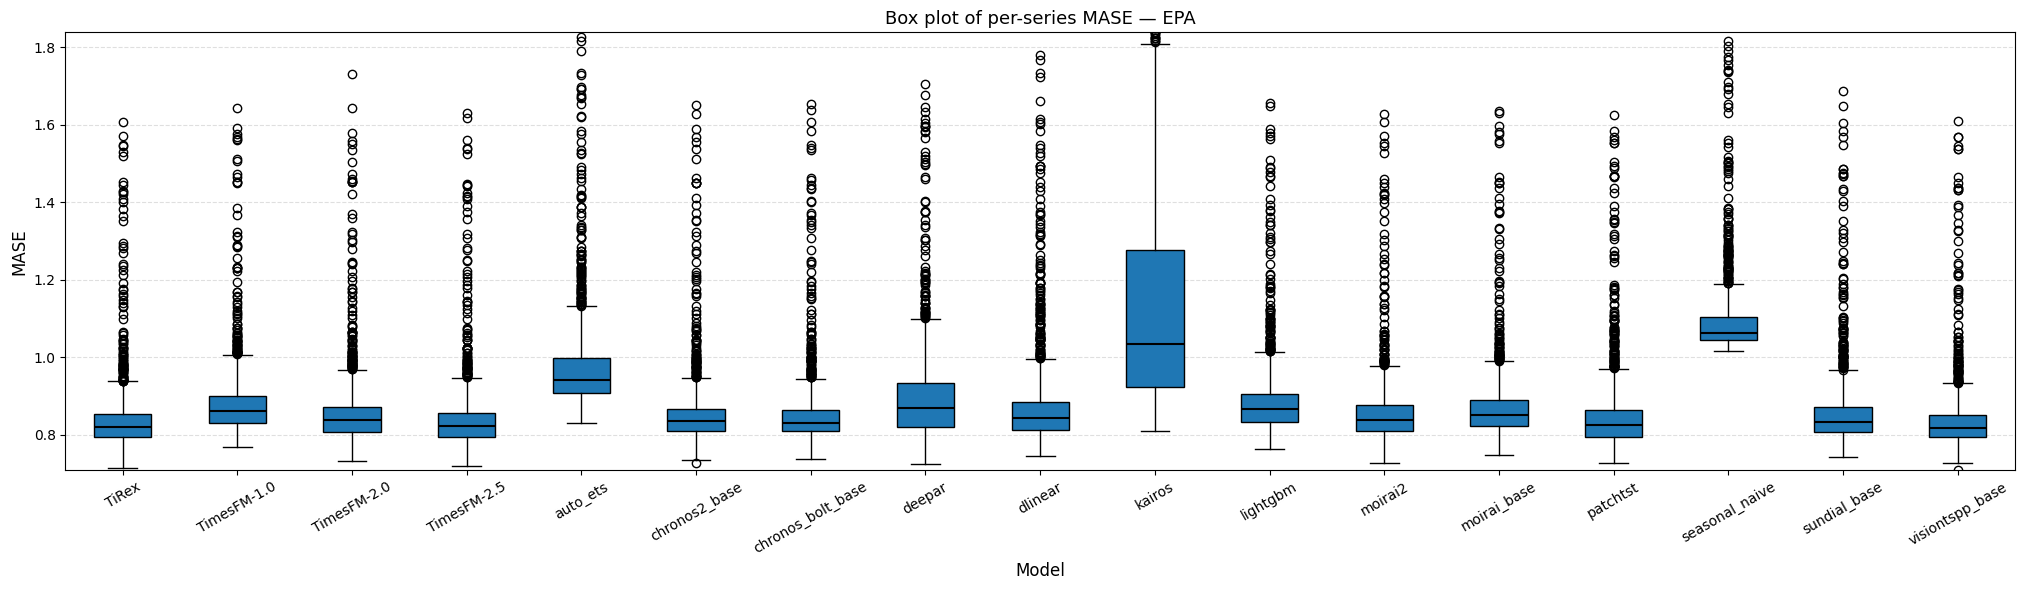

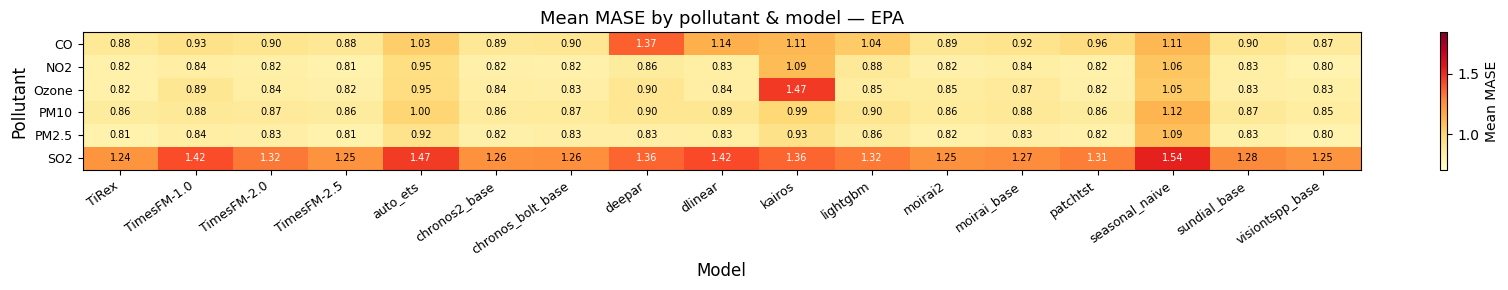

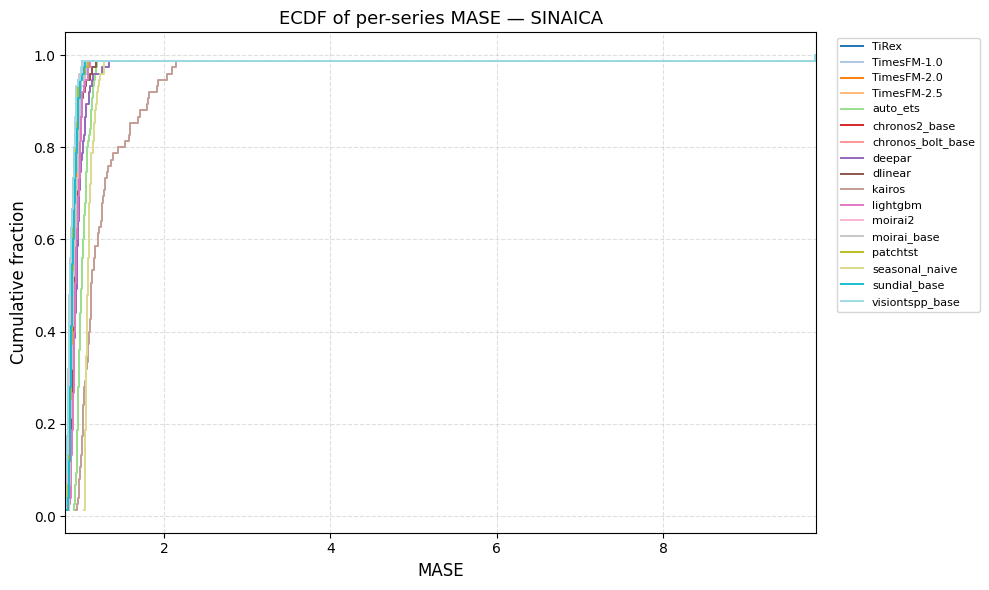

/tmp/ipykernel_70059/3114967861.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


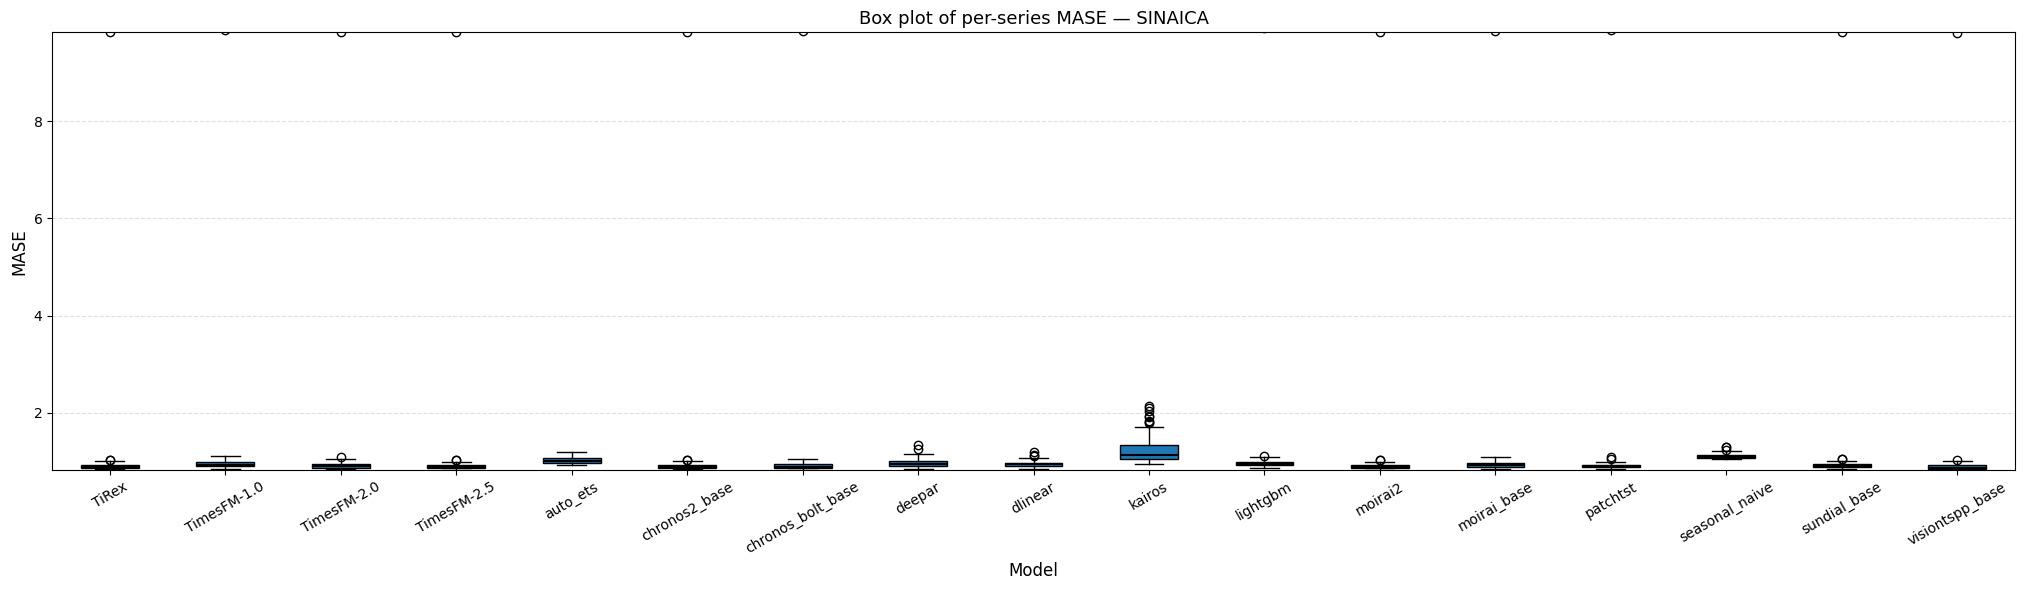

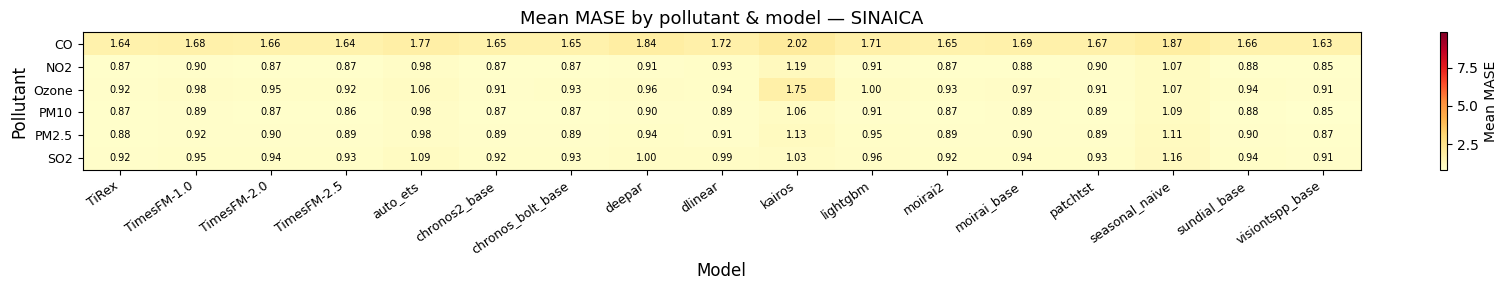

In [5]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path(".").resolve()))
sys.path.insert(0, str(Path("scripts").resolve()))

from compute_local_leaderboard import _iter_model_series
from leaderboard_utils import extract_pollutant, display_dataset

RESULTS_ROOT = Path("output/results")
PERCENTILE   = 99
THRESHOLD    = 50  # exclude sites where mean MASE or CRPS > threshold across models

# ── Discover all dataset_ids present in results ───────────────────────────────
dataset_ids = sorted({
    f"{d.name}/{f.name}"
    for model_dir in RESULTS_ROOT.iterdir() if model_dir.is_dir()
    for d in model_dir.iterdir() if d.is_dir()
    for f in d.iterdir() if f.is_dir()
})

# ── Pass 1: collect per-site MASE & CRPS across all models to find exclusions ─
# Key: (dataset_id, horizon, item_id) -> list of values across models
site_metric_values: dict[str, dict[tuple[str, str, str], list[float]]] = {"MASE": {}, "CRPS": {}}

for model_name, dataset_id, horizon, item_ids, npz_metrics in _iter_model_series(RESULTS_ROOT):
    n_series = len(item_ids)
    for metric_name in ["MASE", "CRPS"]:
        arr = npz_metrics.get(metric_name)
        if arr is None or arr.shape[0] != n_series:
            continue
        reduce_axes = tuple(range(1, arr.ndim))
        per_series = np.nanmean(arr[:n_series], axis=reduce_axes) if reduce_axes else arr[:n_series]
        for i, iid in enumerate(item_ids):
            val = per_series[i]
            if not np.isnan(val):
                site_metric_values[metric_name].setdefault((dataset_id, horizon, iid), []).append(float(val))

# Determine excluded sites: mean MASE > THRESHOLD or mean CRPS > THRESHOLD
excluded_sites: dict[tuple[str, str], set[str]] = {}
all_site_keys = set(site_metric_values["MASE"]) | set(site_metric_values["CRPS"])
for key in all_site_keys:
    dataset_id, horizon, iid = key
    mase_vals = site_metric_values["MASE"].get(key, [])
    crps_vals = site_metric_values["CRPS"].get(key, [])
    if (mase_vals and np.mean(mase_vals) > THRESHOLD) or (crps_vals and np.mean(crps_vals) > THRESHOLD):
        excluded_sites.setdefault((dataset_id, horizon), set()).add(iid)

if excluded_sites:
    print(f"Threshold ({THRESHOLD}) exclusions — mean MASE>threshold OR mean CRPS>threshold:")
    for (ds, hz), ids in sorted(excluded_sites.items()):
        pollutant_counts: dict[str, int] = {}
        for iid in ids:
            pol = extract_pollutant(iid)
            pollutant_counts[pol] = pollutant_counts.get(pol, 0) + 1
        breakdown = ", ".join(f"{pol}: {n}" for pol, n in sorted(pollutant_counts.items()))
        print(f"  {ds}/{hz}: {len(ids)} site(s) excluded ({breakdown})")

# ── Pass 2: ECDF + Box plot + Heatmap per dataset ────────────────────────────
for dataset_id in dataset_ids:
    ds_label = display_dataset(dataset_id)
    model_mase: dict[str, list[float]] = {}
    pollutant_records: dict[tuple[str, str], list[float]] = {}

    for model_name, _, horizon, item_ids, npz_metrics in _iter_model_series(
        RESULTS_ROOT, [dataset_id]
    ):
        arr = npz_metrics.get("MASE")
        if arr is None:
            continue
        n_series = len(item_ids)
        reduce_axes = tuple(range(1, arr.ndim))
        per_series = np.nanmean(arr[:n_series], axis=reduce_axes) if reduce_axes else arr[:n_series]

        exclude_ids = excluded_sites.get((dataset_id, horizon), set())
        for i, iid in enumerate(item_ids):
            if iid in exclude_ids:
                per_series[i] = np.nan

        model_mase.setdefault(model_name, []).extend(per_series.tolist())
        for i, iid in enumerate(item_ids):
            val = per_series[i]
            if not np.isnan(val):
                pollutant_records.setdefault((model_name, extract_pollutant(iid)), []).append(val)

    if not model_mase:
        continue

    all_vals = [v for vals in model_mase.values() for v in vals if not np.isnan(v)]
    x_max = float(np.percentile(all_vals, PERCENTILE))
    x_min = float(np.percentile(all_vals, 0))

    sorted_names = sorted(model_mase.keys())
    colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_names)))

    # ── ECDF ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    for idx, model_name in enumerate(sorted_names):
        values = model_mase[model_name]
        vals = np.sort([v for v in values if not np.isnan(v)])
        ecdf = np.arange(1, len(vals) + 1) / len(vals)
        ax.step(vals, ecdf, label=model_name, where="post", linewidth=1.4, color=colors[idx])

    ax.set_xlim(left=x_min, right=x_max)
    ax.set_xlabel("MASE", fontsize=12)
    ax.set_ylabel("Cumulative fraction", fontsize=12)
    ax.set_title(f"ECDF of per-series MASE — {ds_label}", fontsize=13)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, framealpha=0.8)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ── Box plot ──────────────────────────────────────────────────────────────
    data = [[v for v in model_mase[m] if not np.isnan(v)] for m in sorted_names]

    fig, ax = plt.subplots(figsize=(max(8, len(sorted_names) * 1.2), 6))
    ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})
    ax.set_xlim(0.5, len(sorted_names) + 0.5)
    ax.set_ylim(bottom=x_min, top=x_max)
    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("MASE", fontsize=12)
    ax.set_title(f"Box plot of per-series MASE — {ds_label}", fontsize=13)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ── Pollutant × Model heatmap ────────────────────────────────────────────
    pollutants = sorted({p for _, p in pollutant_records})

    matrix = np.full((len(pollutants), len(sorted_names)), np.nan)
    for j, model in enumerate(sorted_names):
        for i, pol in enumerate(pollutants):
            vals = pollutant_records.get((model, pol))
            if vals:
                matrix[i, j] = np.nanmean(vals)

    # vmax = float(np.nanpercentile(matrix[~np.isnan(matrix)], PERCENTILE))
    # vmin = float(np.nanpercentile(matrix[~np.isnan(matrix)], 0))

    fig, ax = plt.subplots(figsize=(max(6, len(sorted_names) * 1.0), max(3, len(pollutants) * 0.5)))
    im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd", vmin=x_min, vmax=x_max)
    plt.colorbar(im, ax=ax, label="Mean MASE")

    ax.set_xticks(range(len(sorted_names)))
    ax.set_xticklabels(sorted_names, rotation=35, ha="right", fontsize=9)
    ax.set_yticks(range(len(pollutants)))
    ax.set_yticklabels(pollutants, fontsize=9)
    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("Pollutant", fontsize=12)
    ax.set_title(f"Mean MASE by pollutant & model — {ds_label}", fontsize=13)

    for i in range(len(pollutants)):
        for j in range(len(sorted_names)):
            v = matrix[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="black" if v < x_max * 0.7 else "white")

    plt.tight_layout()
    plt.show()


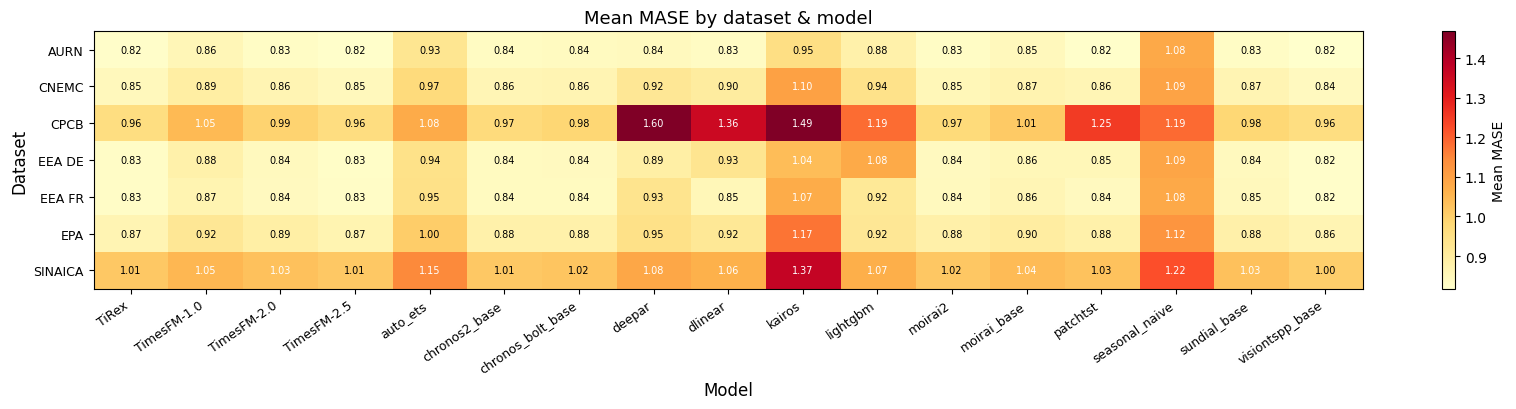

In [6]:

from leaderboard_utils import display_dataset

# ── Dataset (country) × Model MASE heatmap ───────────────────────────────────
dataset_records: dict[tuple[str, str], list[float]] = {}

for dataset_id in dataset_ids:
    for model_name, _, horizon, item_ids, npz_metrics in _iter_model_series(
        RESULTS_ROOT, [dataset_id]
    ):
        arr = npz_metrics.get("MASE")
        if arr is None:
            continue
        n_series = len(item_ids)
        reduce_axes = tuple(range(1, arr.ndim))
        per_series = np.nanmean(arr[:n_series], axis=reduce_axes) if reduce_axes else arr[:n_series]

        exclude_ids = excluded_sites.get((dataset_id, horizon), set())
        for i, iid in enumerate(item_ids):
            if iid in exclude_ids:
                per_series[i] = np.nan

        clean = [v for v in per_series.tolist() if not np.isnan(v)]
        if clean:
            dataset_records.setdefault((model_name, display_dataset(dataset_id)), []).extend(clean)

models   = sorted({m for m, _ in dataset_records})
datasets = sorted({d for _, d in dataset_records})

matrix = np.full((len(datasets), len(models)), np.nan)
for j, model in enumerate(models):
    for i, ds in enumerate(datasets):
        vals = dataset_records.get((model, ds))
        if vals:
            matrix[i, j] = np.nanmean(vals)

vmax = float(np.nanpercentile(matrix[~np.isnan(matrix)], PERCENTILE))
vmin = float(np.nanpercentile(matrix[~np.isnan(matrix)], 0))

fig, ax = plt.subplots(figsize=(max(6, len(models) * 1.0), max(3, len(datasets) * 0.6)))
im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd", vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, label="Mean MASE")

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(datasets)))
ax.set_yticklabels(datasets, fontsize=9)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Dataset", fontsize=12)
ax.set_title("Mean MASE by dataset & model", fontsize=13)

for i in range(len(datasets)):
    for j in range(len(models)):
        v = matrix[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="black" if v < vmax * 0.7 else "white")

plt.tight_layout()
plt.show()


In [7]:
0.96/1.19

0.8067226890756303

In [8]:
1/1.22

0.819672131147541